# YOLO Pose Inference Tests 

This notebook helps you test YOLO pose inference against the CHIMP serving API.

What is included:
- Image preprocessing to the expected model format (NCHW, float32, 640x640)
- API call to `/model/<model_name>/infer`
- Basic visualization of returned bounding boxes and keypoints
- Small helper snippets for quick repeated tests

In [37]:
from pathlib import Path
import json

import cv2
import numpy as np
import requests
import matplotlib.pyplot as plt

In [38]:
SERVING_API_URL = "http://localhost:5254"
MODEL_NAME = "yolo_pose_demo"
IMAGE_PATH = Path("images/pose2.jpg")

STAGE = "production"
SESSION_ID = ""

In [39]:
def preprocess_image_for_yolo_pose(image_path: Path, size: int = 640):
    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise ValueError(f"Could not read image: {image_path}")

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(rgb, (size, size), interpolation=cv2.INTER_LINEAR)

    # Model expects NCHW float32 with values in [0, 1]
    x = resized.transpose(2, 0, 1)[None].astype(np.float32) / 255.0
    return rgb, resized, x

Input shape: (1, 3, 640, 640) dtype: float32 min/max: 0.0 1.0


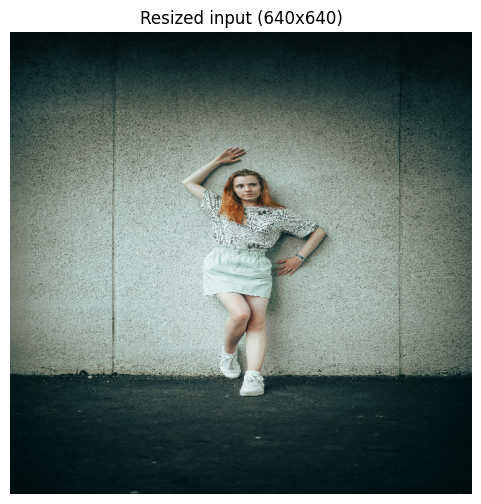

In [40]:
original_rgb, resized_rgb, model_input = preprocess_image_for_yolo_pose(IMAGE_PATH, size=640)
print("Input shape:", model_input.shape, "dtype:", model_input.dtype, "min/max:", model_input.min(), model_input.max())

plt.figure(figsize=(6, 6))
plt.imshow(resized_rgb)
plt.title("Resized input (640x640)")
plt.axis("off")
plt.show()

In [41]:
infer_url = f"{SERVING_API_URL}/model/{MODEL_NAME}/infer"
params = {"stage": STAGE}
if SESSION_ID:
    params["id"] = SESSION_ID

payload = {"inputs": model_input.tolist()}
try:
    response = requests.post(infer_url, params=params, json=payload, timeout=180)
except requests.exceptions.ConnectionError as exc:
    raise RuntimeError(
        f"Could not connect to {infer_url}. Ensure serving_api is running and reachable. "
        "For CHIMP defaults, use http://localhost:5254."
    ) from exc

print("Status:", response.status_code)

try:
    result = response.json()
except ValueError:
    print(response.text)
    raise

print(json.dumps(result, indent=2)[:3000])

Status: 200
{
  "metadata": {
    "artifact_path": "model",
    "flavors": {
      "onnx": {
        "code": null,
        "data": "model.onnx",
        "onnx_session_options": null,
        "onnx_version": "1.17.0",
        "providers": [
          "CUDAExecutionProvider",
          "CPUExecutionProvider"
        ]
      },
      "python_function": {
        "data": "model.onnx",
        "env": {
          "conda": "conda.yaml",
          "virtualenv": "python_env.yaml"
        },
        "loader_module": "mlflow.onnx",
        "python_version": "3.11.15"
      }
    },
    "mlflow_version": "2.11.3",
    "model_size_bytes": 11819314,
    "model_uuid": "2e54759944634f93ba7073ceaa810ea8",
    "run_id": "7ffa4f2d3ed74d3a818bfb38f954ea10",
    "utc_time_created": "2026-03-17 11:18:10.639883"
  },
  "predictions": {
    "output0": [
      [
        [
          10.293384552001953,
          17.97886085510254,
          26.107013702392578,
          32.41986083984375,
          38.067550659

In [42]:
def xywh_to_xyxy(boxes: np.ndarray) -> np.ndarray:
    xyxy = np.zeros_like(boxes)
    xyxy[:, 0] = boxes[:, 0] - (boxes[:, 2] / 2.0)
    xyxy[:, 1] = boxes[:, 1] - (boxes[:, 3] / 2.0)
    xyxy[:, 2] = boxes[:, 0] + (boxes[:, 2] / 2.0)
    xyxy[:, 3] = boxes[:, 1] + (boxes[:, 3] / 2.0)
    return xyxy


def nms_indices(boxes_xyxy: np.ndarray, scores: np.ndarray, iou_threshold: float = 0.45) -> np.ndarray:
    if len(boxes_xyxy) == 0:
        return np.array([], dtype=np.int32)

    x1 = boxes_xyxy[:, 0]
    y1 = boxes_xyxy[:, 1]
    x2 = boxes_xyxy[:, 2]
    y2 = boxes_xyxy[:, 3]
    areas = np.maximum(0.0, x2 - x1) * np.maximum(0.0, y2 - y1)
    order = scores.argsort()[::-1]

    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(i)
        if order.size == 1:
            break

        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])

        w = np.maximum(0.0, xx2 - xx1)
        h = np.maximum(0.0, yy2 - yy1)
        inter = w * h
        union = areas[i] + areas[order[1:]] - inter
        iou = np.where(union > 0.0, inter / union, 0.0)

        remaining = np.where(iou <= iou_threshold)[0]
        order = order[remaining + 1]

    return np.array(keep, dtype=np.int32)


def decode_yolo_pose_output(raw_output, conf_threshold: float = 0.10, iou_threshold: float = 0.45):
    out = np.asarray(raw_output, dtype=np.float32)
    if out.ndim != 3 or out.shape[0] < 1:
        return []

    pred = np.transpose(out[0], (1, 0)) if out.shape[1] <= out.shape[2] else out[0]
    if pred.shape[1] < 6:
        return []

    scores = pred[:, 4]
    mask = scores >= conf_threshold
    pred = pred[mask]
    scores = scores[mask]
    if len(pred) == 0:
        return []

    boxes_xywh = pred[:, :4]
    boxes_xyxy = xywh_to_xyxy(boxes_xywh)
    keep = nms_indices(boxes_xyxy, scores, iou_threshold=iou_threshold)

    detections = []
    for i in keep:
        row = pred[i]
        keypoint_values = row[5:]
        keypoints = []
        if len(keypoint_values) >= 3:
            kp = keypoint_values.reshape(-1, 3)
            keypoints = [
                {"x": float(point[0]), "y": float(point[1]), "confidence": float(point[2])}
                for point in kp
            ]

        detections.append(
            {
                "confidence": float(row[4]),
                "bbox_xywh": [float(v) for v in row[:4]],
                "bbox_xyxy": [float(v) for v in boxes_xyxy[i]],
                "keypoints": keypoints,
            }
        )

    return detections


def draw_pose_detections(image_rgb: np.ndarray, detections, kp_conf_threshold: float = 0.2):
    canvas = image_rgb.copy()

    for det in detections:
        x1, y1, x2, y2 = det.get("bbox_xyxy", [0, 0, 0, 0])
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
        cv2.rectangle(canvas, (x1, y1), (x2, y2), (0, 255, 0), 2)

        for kp in det.get("keypoints", []):
            if kp.get("confidence", 0.0) < kp_conf_threshold:
                continue
            xk = int(kp["x"])
            yk = int(kp["y"])
            cv2.circle(canvas, (xk, yk), 3, (255, 0, 0), -1)

    return canvas

Using output tensor: output0 with shape (1, 56, 8400)
Detections: 1


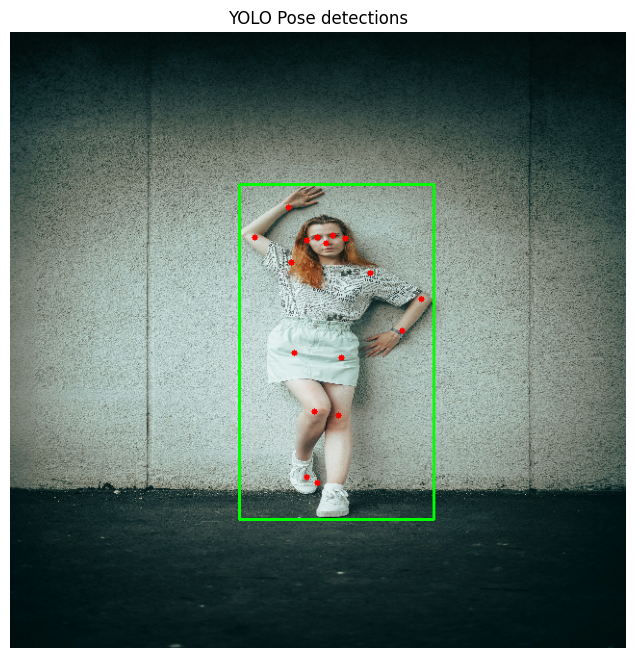

In [34]:
predictions = result.get("predictions", {})
if not isinstance(predictions, dict) or not predictions:
    raise ValueError("No predictions found in serving response")

if "raw" in predictions and isinstance(predictions["raw"], dict):
    raw_outputs = predictions["raw"]
else:
    raw_outputs = predictions

if not isinstance(raw_outputs, dict) or not raw_outputs:
    raise ValueError(
        "Expected prediction tensors under predictions['raw'] or directly under predictions. "
        f"Got keys: {list(predictions.keys())}"
    )

first_output_name, first_output_value = next(iter(raw_outputs.items()))
first_output = np.asarray(first_output_value, dtype=np.float32)
print("Using output tensor:", first_output_name, "with shape", first_output.shape)

pose_detections = decode_yolo_pose_output(first_output)
print("Detections:", len(pose_detections))

vis = draw_pose_detections(resized_rgb, pose_detections)
plt.figure(figsize=(8, 8))
plt.imshow(vis)
plt.title("YOLO Pose detections")
plt.axis("off")
plt.show()

## Minimal Video Support (Frame-by-Frame via Existing Inference API)

This section adds minimal video support without backend changes.

It works by:
- reading frames from a local video
- sampling frames (for example, every 2nd frame)
- sending each sampled frame to `/model/<model_name>/infer`
- decoding and drawing YOLO pose detections
- writing an annotated output video
- saving per-frame detections to JSON

In [ ]:
VIDEO_PATH = Path("videos/pose_demo.mp4")
OUTPUT_VIDEO_PATH = Path("videos/pose_demo_annotated.mp4")
OUTPUT_JSON_PATH = Path("videos/pose_demo_detections.json")

FRAME_STRIDE = 1 
VIDEO_IMG_SIZE = 640
VIDEO_TIMEOUT_SECONDS = 180


def preprocess_frame_for_yolo_pose(frame_bgr: np.ndarray, size: int = 640):
    rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(rgb, (size, size), interpolation=cv2.INTER_LINEAR)
    x = resized.transpose(2, 0, 1)[None].astype(np.float32) / 255.0
    return resized, x


def infer_pose_for_tensor(model_input: np.ndarray):
    infer_url = f"{SERVING_API_URL}/model/{MODEL_NAME}/infer"
    params = {"stage": STAGE}
    if SESSION_ID:
        params["id"] = SESSION_ID

    payload = {"inputs": model_input.tolist()}
    response = requests.post(infer_url, params=params, json=payload, timeout=VIDEO_TIMEOUT_SECONDS)
    response.raise_for_status()

    result = response.json()
    predictions = result.get("predictions")
    if not isinstance(predictions, dict) or not predictions:
        return []

    raw_outputs = predictions.get("raw", predictions)
    if not isinstance(raw_outputs, dict) or not raw_outputs:
        return []

    first_output = np.asarray(next(iter(raw_outputs.values())), dtype=np.float32)
    return decode_yolo_pose_output(first_output)


def transcode_to_h264(input_path: Path, output_path: Path):
    import shutil
    import subprocess

    ffmpeg_path = shutil.which("ffmpeg")
    if not ffmpeg_path:
        raise RuntimeError("ffmpeg is required but was not found on PATH")

    cmd = [
        ffmpeg_path,
        "-y",
        "-i",
        str(input_path),
        "-c:v",
        "libx264",
        "-pix_fmt",
        "yuv420p",
        "-movflags",
        "+faststart",
        "-an",
        str(output_path),
    ]

    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(
            "ffmpeg transcoding failed.\n"
            + result.stderr[-2000:]
        )


def run_video_pose_inference(
    video_path: Path,
    output_video_path: Path,
    output_json_path: Path,
    frame_stride: int = 2,
    size: int = 640,
):
    if not video_path.exists():
        raise FileNotFoundError(f"Video not found: {video_path}")
    if frame_stride < 1:
        raise ValueError("frame_stride must be >= 1")

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    fps = fps if fps and fps > 0 else 25.0

    output_video_path.parent.mkdir(parents=True, exist_ok=True)
    output_json_path.parent.mkdir(parents=True, exist_ok=True)

    temp_video_path = output_video_path.with_name(output_video_path.stem + "_temp.mp4")

    writer = cv2.VideoWriter(
        str(temp_video_path),
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (size, size),
    )

    frame_idx = 0
    sampled_idx = 0
    results = []

    try:
        while True:
            ok, frame_bgr = cap.read()
            if not ok:
                break

            if frame_idx % frame_stride != 0:
                frame_idx += 1
                continue

            resized_rgb, model_input = preprocess_frame_for_yolo_pose(frame_bgr, size=size)
            detections = infer_pose_for_tensor(model_input)
            vis_rgb = draw_pose_detections(resized_rgb, detections)
            vis_bgr = cv2.cvtColor(vis_rgb, cv2.COLOR_RGB2BGR)
            writer.write(vis_bgr)

            results.append(
                {
                    "frame_index": int(frame_idx),
                    "sample_index": int(sampled_idx),
                    "detections": detections,
                }
            )

            sampled_idx += 1
            frame_idx += 1

            if sampled_idx % 10 == 0:
                print(f"Processed sampled frames: {sampled_idx}")
    finally:
        cap.release()
        writer.release()

    transcode_to_h264(temp_video_path, output_video_path)
    if temp_video_path.exists():
        temp_video_path.unlink()

    output_json_path.write_text(json.dumps(results, indent=2), encoding="utf-8")

    return {
        "video_out": str(output_video_path),
        "json_out": str(output_json_path),
        "sampled_frames": sampled_idx,
    }

In [36]:
from IPython.display import Video, display

summary = run_video_pose_inference(
    video_path=VIDEO_PATH,
    output_video_path=OUTPUT_VIDEO_PATH,
    output_json_path=OUTPUT_JSON_PATH,
    frame_stride=FRAME_STRIDE,
    size=VIDEO_IMG_SIZE,
)
print(json.dumps(summary, indent=2))

video_out_path = Path(summary["video_out"])
if video_out_path.exists():
    display(Video(str(video_out_path), embed=True))
else:
    print(f"Could not find output video at {video_out_path}")

Processed sampled frames: 10
Processed sampled frames: 20
Processed sampled frames: 30
Processed sampled frames: 40
Processed sampled frames: 50
Processed sampled frames: 60
Processed sampled frames: 70
Processed sampled frames: 80
Processed sampled frames: 90
Processed sampled frames: 100
Processed sampled frames: 110
Processed sampled frames: 120
Processed sampled frames: 130
Processed sampled frames: 140
Processed sampled frames: 150
{
  "video_out": "videos\\pose_demo_annotated.mp4",
  "json_out": "videos\\pose_demo_detections.json",
  "sampled_frames": 151
}
